In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns



In [26]:
df = pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [3]:
df.isna().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

<Axes: xlabel='HeartDisease'>

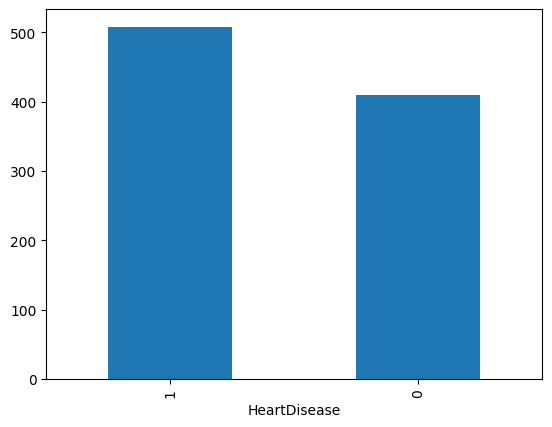

In [12]:
df['HeartDisease'].value_counts().plot(kind= 'bar')


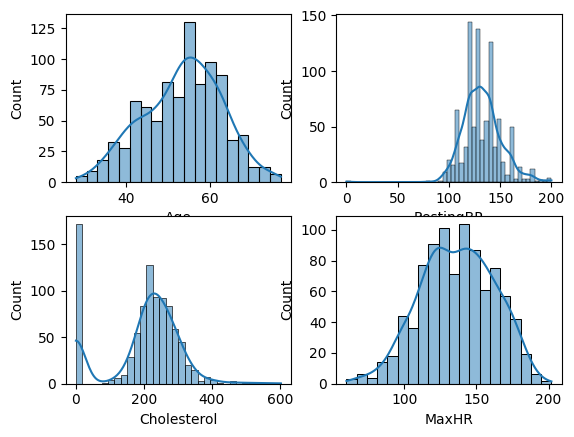

In [ ]:
def graph(col,num):
    plt.subplot(2,2,num)
    sns.histplot(x=df[col],kde = True)
    
graph('Age',1)
graph('RestingBP',2)
graph('Cholesterol',3)
graph('MaxHR',4)



In [5]:
df.Cholesterol.value_counts()

Cholesterol
0      172
254     11
223     10
220     10
211      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

In [28]:
me = df[df.Cholesterol !=0].Cholesterol.mean()
me
df.Cholesterol =  df.Cholesterol.replace(0,me)

In [29]:
me = df[df.RestingBP !=0].RestingBP.mean()
me
df.RestingBP =  df.RestingBP.replace(0,me)

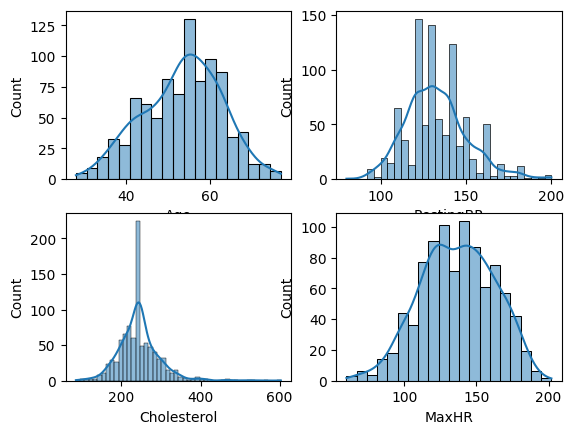

In [30]:
graph('Age',1)
graph('RestingBP',2)
graph('Cholesterol',3)
graph('MaxHR',4)

In [31]:
df.replace(['TA', 'ASY', 'ATA', 'NAP','Normal','LVH', 'ST', 'N', 'Y', 'Up', 'Flat', 'Down'],[4,3,2,1,1,2,3,1,2,1,2,3],inplace=True)
df
df = pd.get_dummies(df,columns=['Sex'],drop_first=True, dtype=int)

In [32]:
df

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Sex_M
0,40,2,140.0,289.0,0,1,172,1,0.0,1,0,1
1,49,1,160.0,180.0,0,1,156,1,1.0,2,1,0
2,37,2,130.0,283.0,0,3,98,1,0.0,1,0,1
3,48,3,138.0,214.0,0,1,108,2,1.5,2,1,0
4,54,1,150.0,195.0,0,1,122,1,0.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,4,110.0,264.0,0,1,132,1,1.2,2,1,1
914,68,3,144.0,193.0,1,1,141,1,3.4,2,1,1
915,57,3,130.0,131.0,0,1,115,2,1.2,2,1,1
916,57,2,130.0,236.0,0,2,174,1,0.0,2,1,0


In [48]:
df

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Sex_M
0,40,2,140.0,289.0,0,1,172,1,0.0,1,0,1
1,49,1,160.0,180.0,0,1,156,1,1.0,2,1,0
2,37,2,130.0,283.0,0,3,98,1,0.0,1,0,1
3,48,3,138.0,214.0,0,1,108,2,1.5,2,1,0
4,54,1,150.0,195.0,0,1,122,1,0.0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,4,110.0,264.0,0,1,132,1,1.2,2,1,1
914,68,3,144.0,193.0,1,1,141,1,3.4,2,1,1
915,57,3,130.0,131.0,0,1,115,2,1.2,2,1,1
916,57,2,130.0,236.0,0,2,174,1,0.0,2,1,0


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score



In [35]:
x = df.drop('HeartDisease', axis  = 1)
y = df.HeartDisease


In [79]:
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=5)
from sklearn.preprocessing import MinMaxScaler
scalar = MinMaxScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.fit_transform(x_test)


In [80]:
scores = []
models = {
    'logistic regression':LogisticRegression(),
    'Decision tree':DecisionTreeClassifier(),
    'SVM' : SVC(),
    'KNN': KNeighborsClassifier(),
    'GNB':GaussianNB()
}
for name,model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    sc = model.score(x_test, y_test)
    acc = accuracy_score(y_test,y_pred)
    f1 = f1_score(y_test, y_pred)
    scores.append({
        'model':name,
        'f1_score':f1,
        'acc':acc,
        'score':sc
    })
for i in scores:
    print(i)



{'model': 'logistic regression', 'f1_score': 0.91324200913242, 'acc': 0.8967391304347826, 'score': 0.8967391304347826}
{'model': 'Decision tree', 'f1_score': 0.7964601769911505, 'acc': 0.75, 'score': 0.75}
{'model': 'SVM', 'f1_score': 0.9272727272727272, 'acc': 0.9130434782608695, 'score': 0.9130434782608695}
{'model': 'KNN', 'f1_score': 0.908256880733945, 'acc': 0.8913043478260869, 'score': 0.8913043478260869}
{'model': 'GNB', 'f1_score': 0.9279279279279279, 'acc': 0.9130434782608695, 'score': 0.9130434782608695}


In [81]:
import joblib
joblib.dump(models['SVM'],'svm.pkl')
joblib.dump(scalar,'scalar.pkl')
joblib.dump(x.columns.tolist(),'cols.pkl')



['cols.pkl']